                     Лабораторный журнал по дз №2: “What causes antibiotic resistance?”

1) Для начала была создана папка project2, а в ней папка raw_data, куда затем скачивались все данные для работы по проекту.

2) Чтобы скачать референсный геном *E.coli* strain K-12 substrain MG1655 и его аннотацию, а также сырые прочтения генома резистентной к антибиотикам *E.coli* использовали команду wget.

In [ ]:
 wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz
 wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gff.gz

3. Так как все файлы скачаны в сжатом формате, то необходимо их распаковать с помощью команды gunzip (для файлов формата .gz) и unzip (для файлов формата .zip) .

In [ ]:
gunzip GCF_000005845.2_ASM584v2_genomic.fna.gz
gunzip GCF_000005845.2_ASM584v2_genomic.gff.gz
unzip amp_res_1.fastq.zip
unzip amp_res_2.fastq.zip

4. Затем необходимо вручную проверить полноту данных и правильность скачанного формата, просмотрев несколько первых строк командой head.

In [ ]:
head -20 GCF_000005845.2_ASM584v2_genomic.fna
head  GCF_000005845.2_ASM584v2_genomic.gff
head -20 amp_res_1.fastq
head -20 amp_res_2.fastq

5. Следующим действием проверили кол-во строк в ридах 1 и 2 с помощью команды wc -l и отметили, что и в amp_res_1.fastq и в
amp_res_2.fastq 1823504 строк, следовательно, каждой строке соответствует своя пара, что важно для парных прочтений.

In [ ]:
wc -l amp_res_1.fastq
wc -l amp_res_2.fastq

6. Устанавливаем FastQC для проверки качества данных.

In [ ]:
conda install -c bioconda fastqc

7. Далее непосредственно осуществляем проверку качества сырых ридов.

In [ ]:
fastqc amp_res_1.fastq amp_res_2.fastq -o ../fastqc_results

8. Проанализируем показатели качества данных ридов.

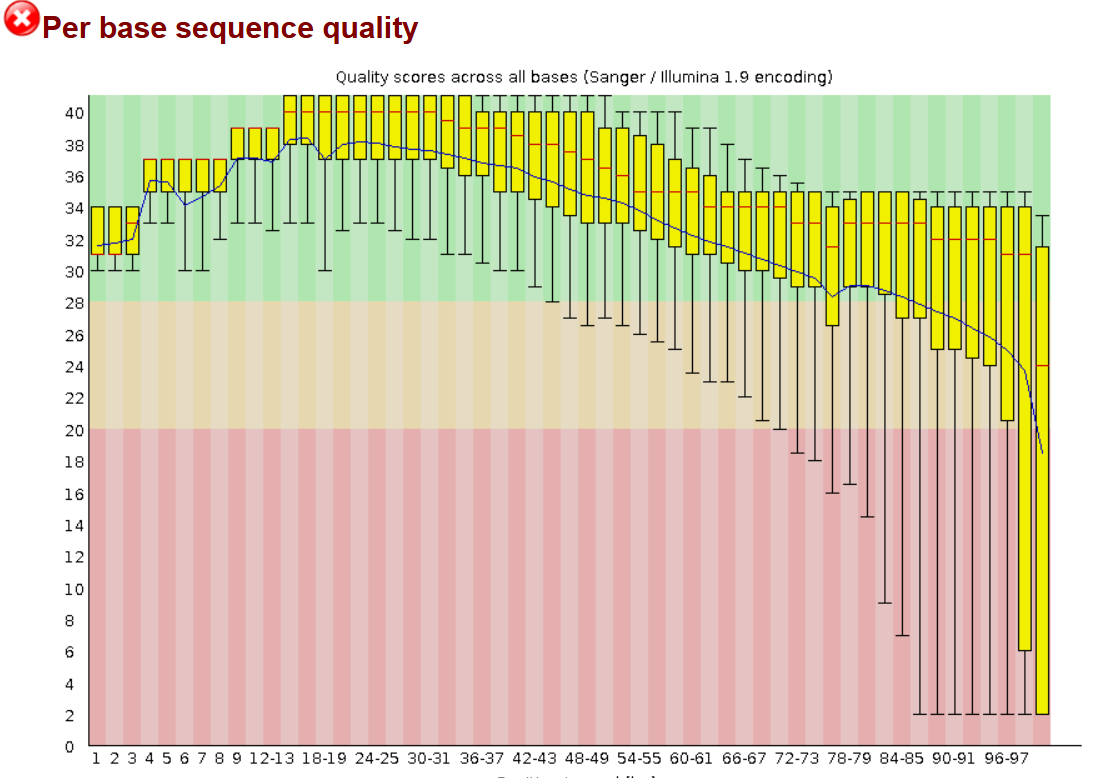

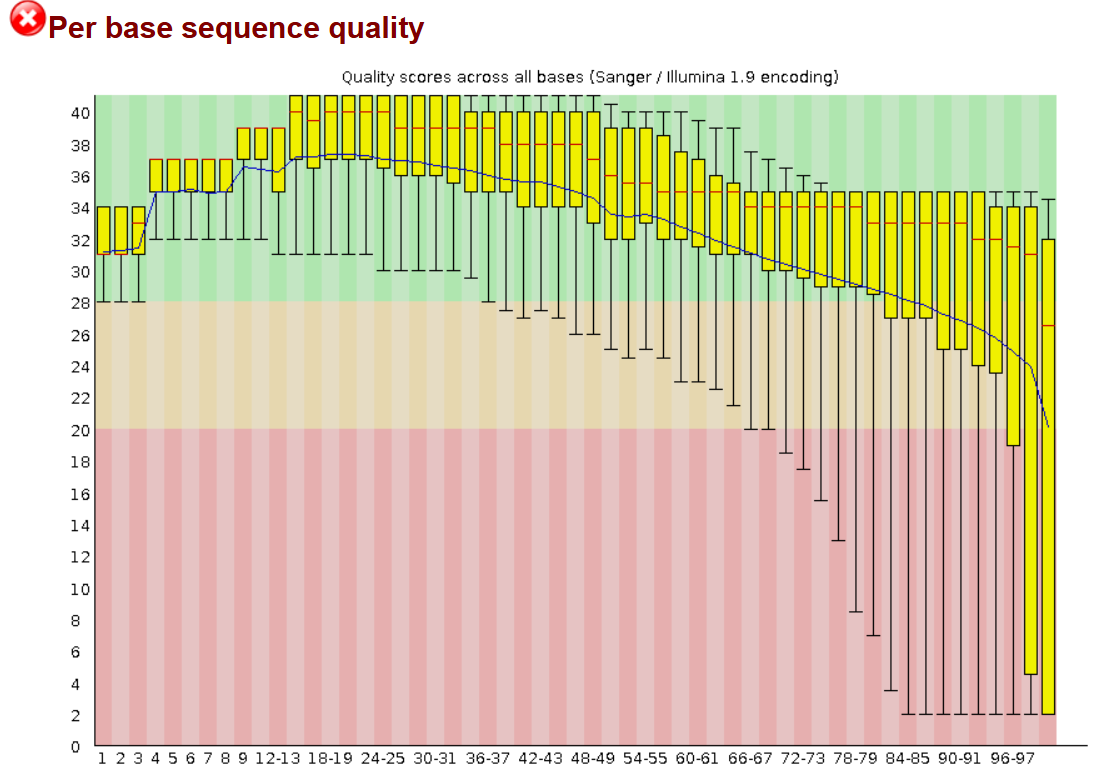

*Вывод:* качество секвенирования нуклеотидов в обоих ридов начинает заметно снижаться к концу ридов, что вполне характерно и типично для Illumina и исправляется с помощью тримминга.

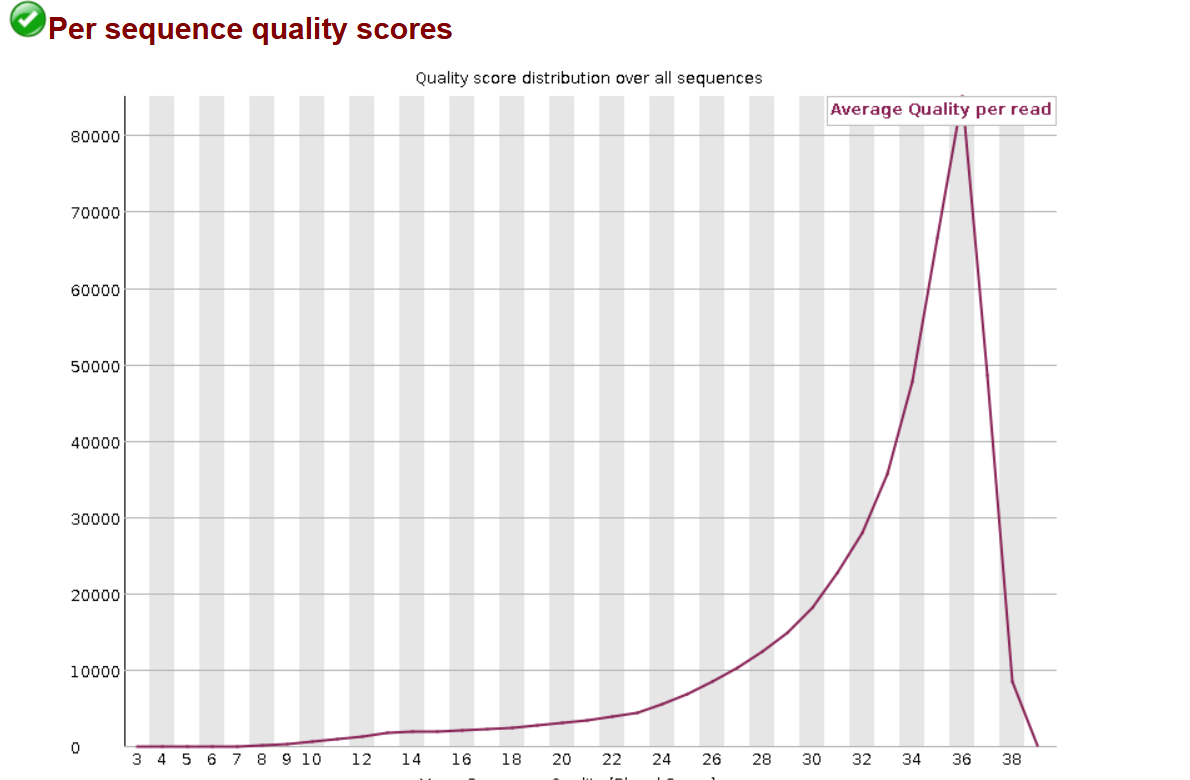

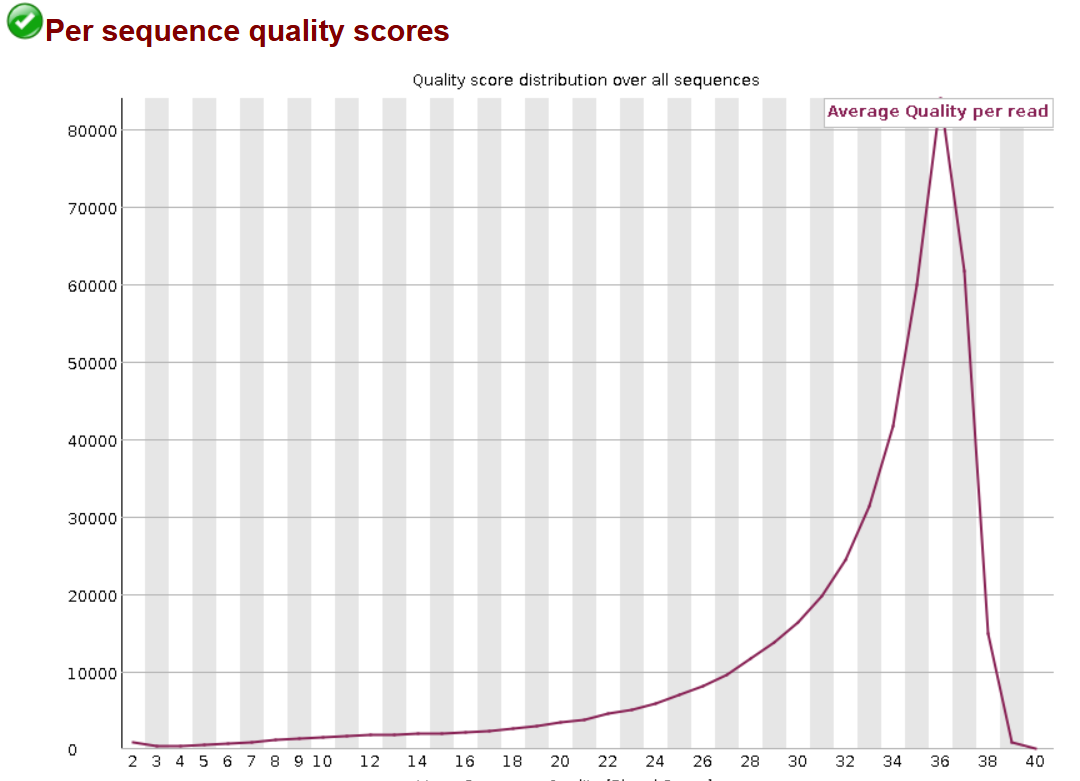

*Вывод:* отмечается ярко выраженный пик в области высоких показателей качества (Q35–37), что указывает на высокое общее качество большинства прочтений и лишь небольшая часть прочтений имеет низкие показатели.

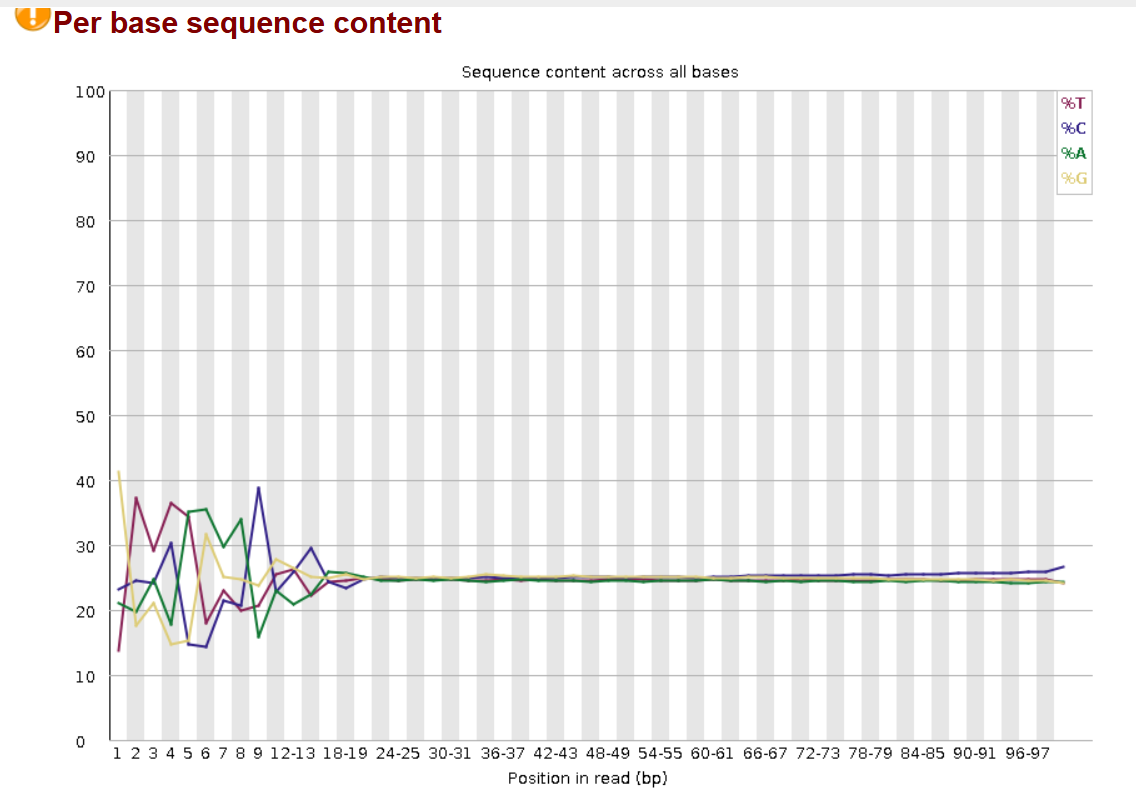

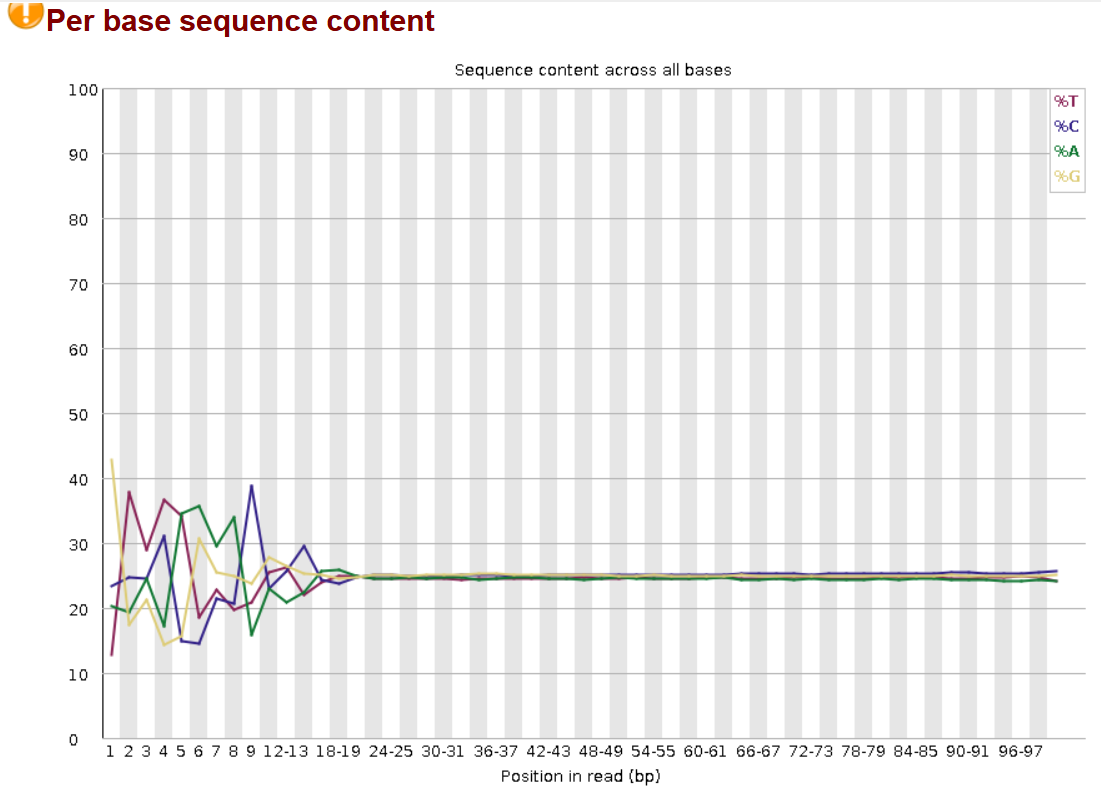

*Вывод:* в первых нуклеотидах (до 13) отмечается небольшая неравномерность, но это типично для секвенирования на платформе Illumina и, вероятно, связано с подготовкой библиотеки. Но затем состав становится более равномерным и стабильным, что говорит о хорошем качестве данных.

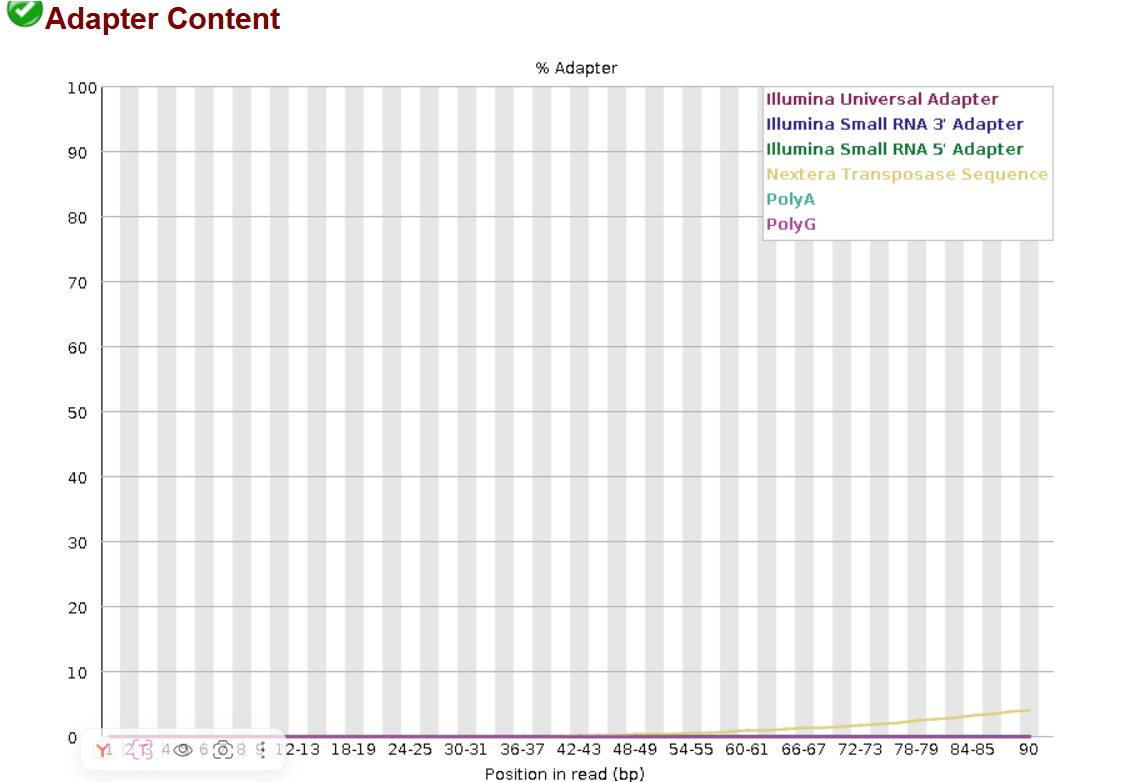

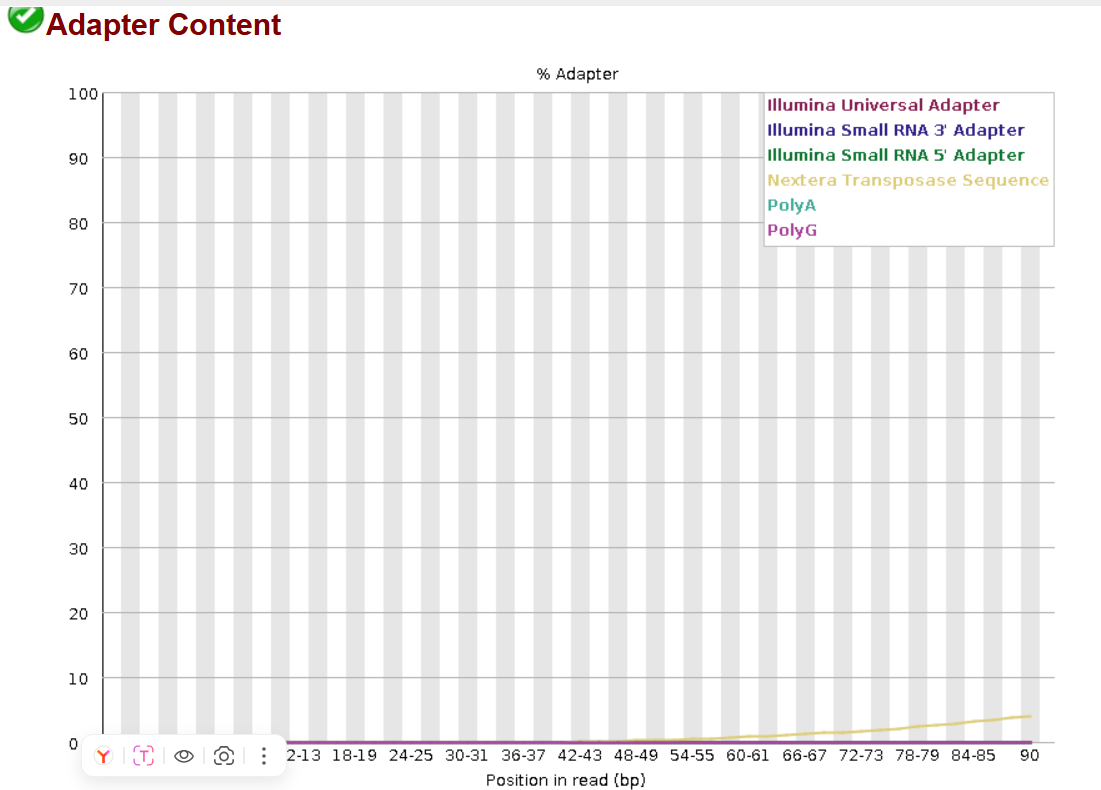

*Вывод:* на большей части длины считывания содержание адаптеров минимально, наблюдается небольшое увеличение содержания адаптеров в конце, что будет удалено во время тримминга.

9. Выполним тримминг с помощью тула trimmomatic.

In [ ]:
trimmomatic PE   amp_res_1.fastq amp_res_2.fastq   trimmed_1_paired.fastq trimmed_1_unpaired.fastq   trimmed_2_paired.fastq trimmed_2_unpaired.fastq   LEADING:20 TRAILING:20 SLIDINGWINDOW:10:20 MINLEN:20

10. Затем проверим, не изменилось ли количество строк в каждом файле и равны ли они после тримминга.

In [ ]:
wc -l trimmed_1_paired.fastq
wc -l trimmed_2_paired.fastq

Теперь в каждом файле по 1785036 строк (1785036/4 = 446259), следовательно, они остаются одинаковыми, что важно для анализа.

11. Выполним проверку качества после тримминга.

In [ ]:
fastqc trimmed_1_paired.fastq  trimmed_2_paired.fastq -o ../fastqc_results

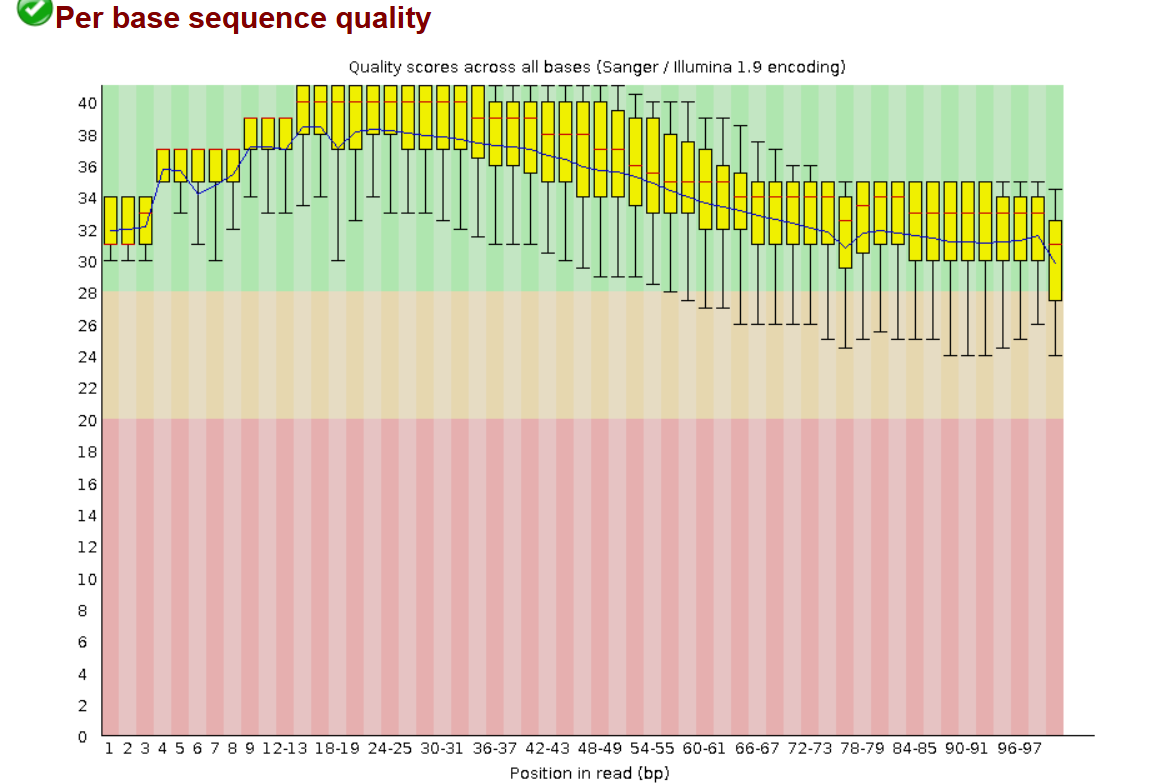

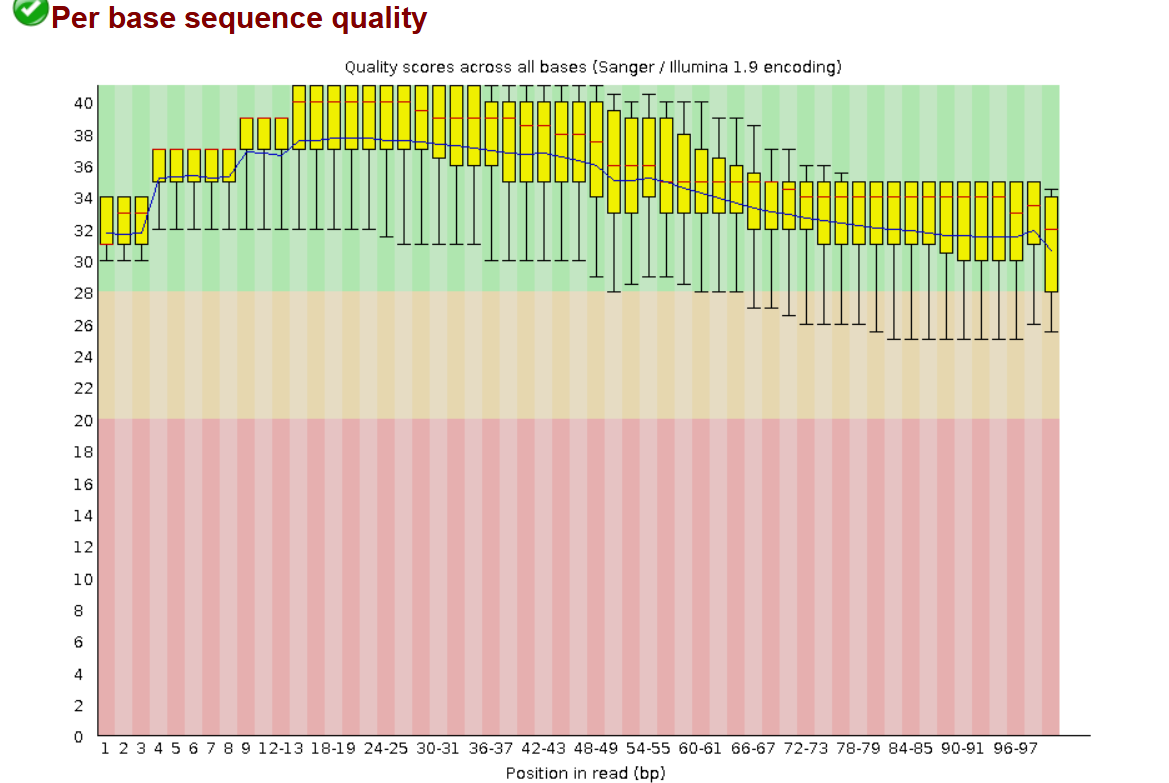

*Вывод:* после тримминга качество последовательности на уровне отдельных оснований значительно улучшилось. Основания низкого качества на концах прочтений были успешно удалены, что позволило добиться стабильно высокого качества для большинства позиций.

Дополнительным этапом анализа стало проведение тримминга, но с изменением показателя качества на 30 на всех этапах.

In [ ]:
trimmomatic PE   amp_res_1.fastq amp_res_2.fastq   trimmed30_1_paired.fastq trimmed30_1_unpaired.fastq   trimmed30_2_paired.fastq trimmed30_2_unpaired.fastq   LEADING:30 TRAILING:30 SLIDINGWINDOW:10:30 MINLEN:30

Далее проверили качество после тримминга с помощью FastQC.

In [ ]:
fastqc trimmed30_1_paired.fastq trimmed30_2_paired.fastq -o ../fastqc_results

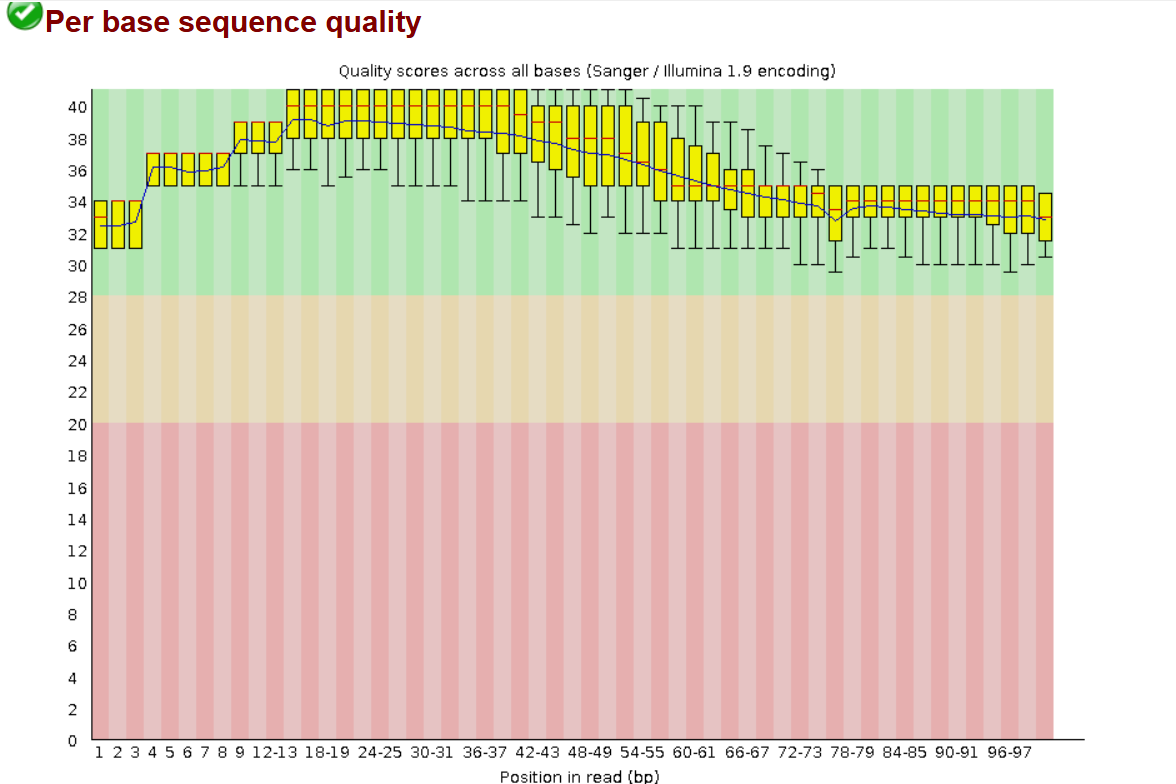

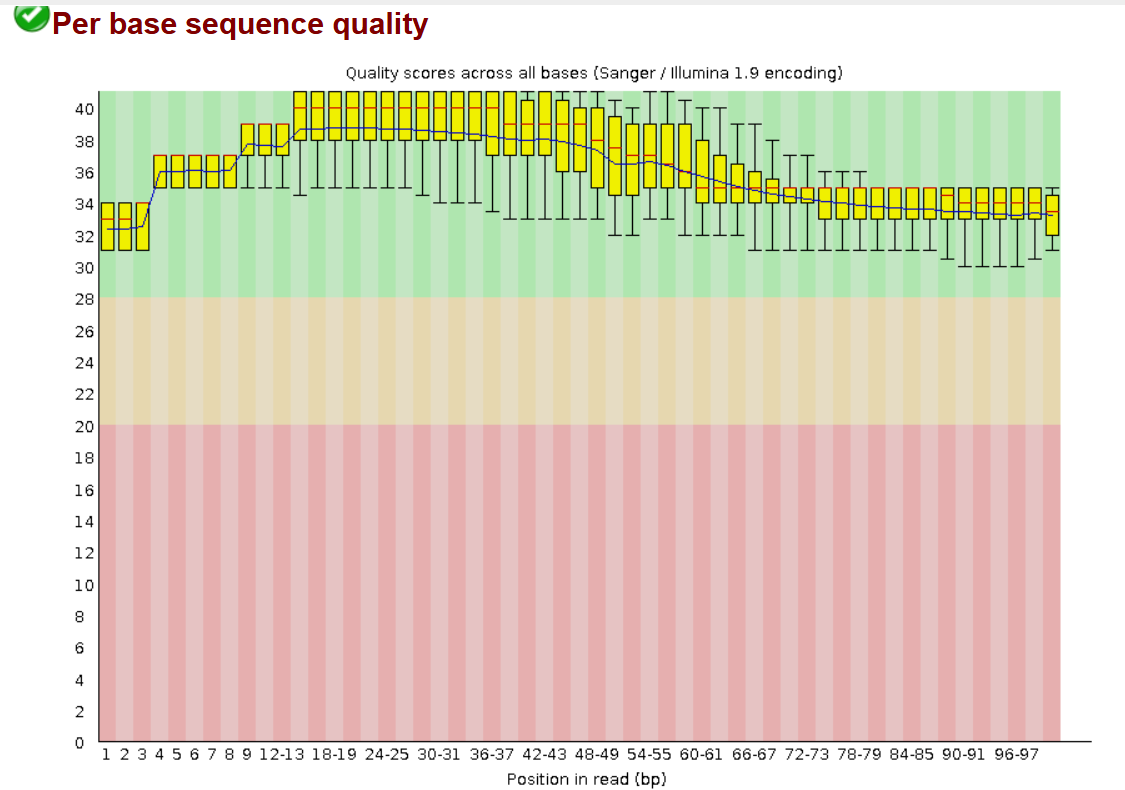

*Вывод:* после тримминга с более жесткими параметрами качество последовательностей на уровне отдельных оснований стало еще выше, все они находятся в зеленом диапазоне (от 28 до 40).

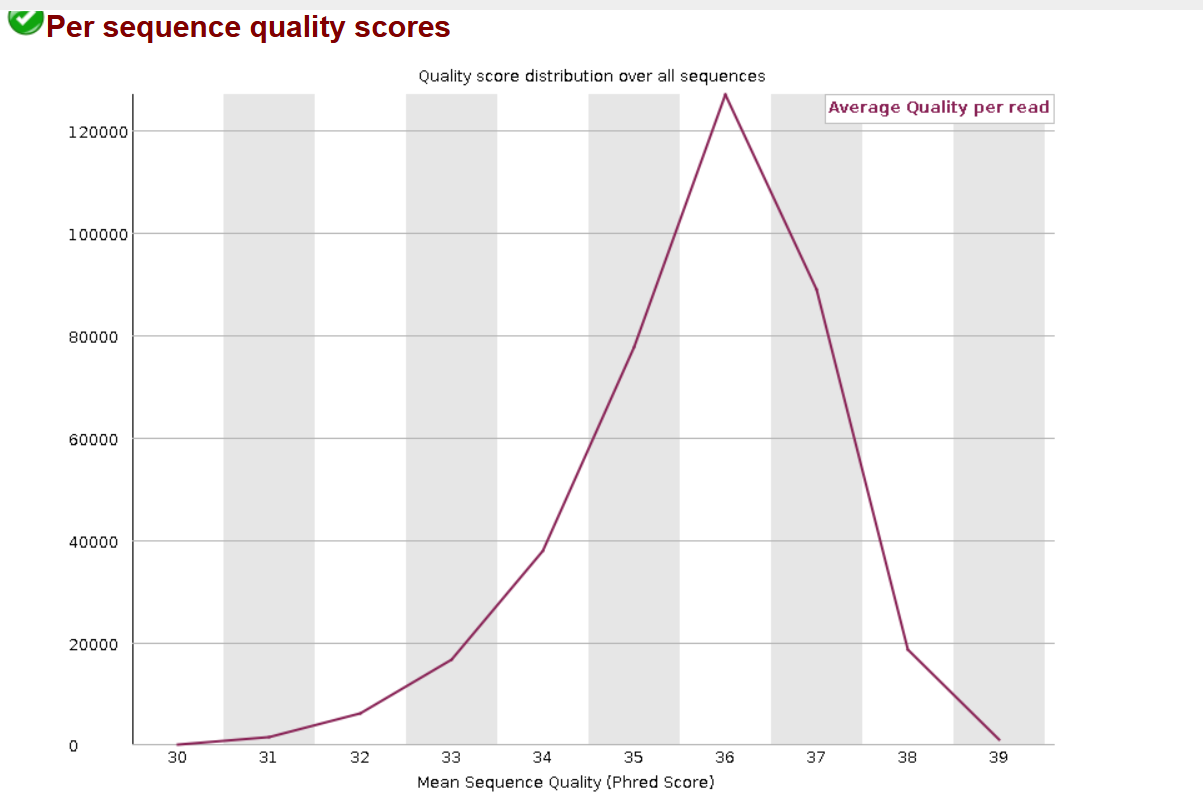

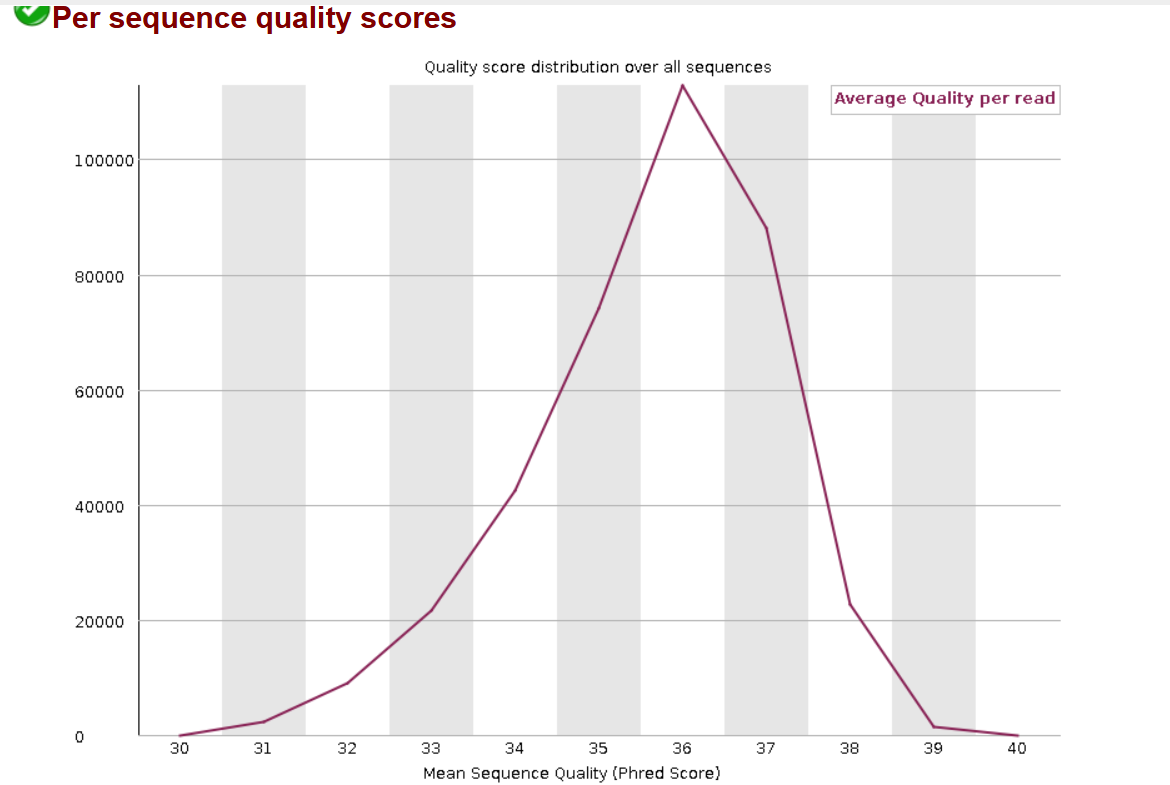

*Вывод:* среднее качество ридов также возросло, большая часть ридов имеют очень высокое качество и риды с качеством ниже 30 отсутствуют.

Можно также проверить оставшееся кол-во строк после более жесткого тримминга.

In [ ]:
wc -l trimmed30_1_paired.fastq
wc -l trimmed30_2_paired.fastq

В каждом файле осталось только 1505360 строк (1505360/4 = 367340), что на 297676 (297676/4 = 69919) строк меньше, чем после более мягкого тримминга.
Таким образом, результатом запуска тримминга (Q30) стало улучшение качества прочтений, но при этом произошло укорочение ридов и наблюдается значительная потеря данных, которые важны для дальнейшего анализа. Следовательно, дальнейшая работа будет вестись с файлами после тримминга (Q20), так как качество этих данных является приемлемым, а сами данные являются более полными по сравнению с более жесткой очисткой.

12. Далее переходим к этапу выравнивания ридов на референс, для этого необходимо установить программу BWA и проверить ее активность.

In [ ]:
conda install -c bioconda bwa
bwa index

Затем переходим к индексации референсного генома.

In [ ]:
bwa index GCF_000005845.2_ASM584v2_genomic.fna

*Вывод:* после индексировании референсного генома с помощью BWA были созданы вспомогательные файлы (.amb, .ann, .bwt, .pac, .sa), которые будут использованы в дальнейшем для выравнивания данных секвенирования на референс.

13. Следующим этапом будет выравнивание ридов на референс с помощью bwa-mem.

In [ ]:
bwa mem GCF_000005845.2_ASM584v2_genomic.fna \
  trimmed_1_paired.fastq trimmed_2_paired.fastq \
  > alignment.sam

В результате получили файл alignment.sam, в котором указано имя рида, имя референса, качество получившегося выравнивания, длина вставки и последовательность. Большинство ридов имеют высокое качество картирования (MAPQ = 60), что указывает на надежное выравнивание по референсному геному.

14. Далее конвертируем alignment.sam в более сжатый формат.

In [ ]:
samtools view -S -b alignment.sam > alignment.bam

Также важно изучить статистические показатели выравнивания и на их основе оценить его успешность.

In [ ]:
samtools flagstat alignment.bam

*Вывол:* суммарно было проанализировано 892776 прочтений, из которых 99,87 % были успешно сопоставлены с референсным геномом. Также важно отметить, что 99,56 % прочтений были правильно спарены, что свидетельствует о высоком качестве данных и точности выравнивания. Среди одиночных прочтений находится лишь малая часть - 0,11 %, что входит в рамки нормы и свидетельствует о минимальной контаминации данных.

15. Затем выполним сортировку и индексацию alignment.bam, что даст возмодность более быстрого поиска по  и извлечения данных благодаря отсортированным по координатам строкам.

In [ ]:
samtools sort alignment.bam -o alignment_sorted.bam
samtools index alignment_sorted.bam

Далее для обеспечения быстрого доступа к участкам референсного генома, необходимо также выполнить его индексацию с помощью samtools faidx.

In [ ]:
samtools faidx GCF_000005845.2_ASM584v2_genomic.fna

На предыдущем этапе мы подготовили данные для загрузки в Integrative Genomics Viewer (IGV).

16. Загрузка данных в IGV.

В IGV загрузили референсный геном и отсортированные на предыдущем этапе сырые данные.

При запуске IGV в интерактивном формате можно посмотреть равномерность покрытия, выровненные риды и SNP (отличающиеся нуклеотиды в программе подсвечиваются другим цветом). А также с помощью данной программы можно переходить к интересующим регионам в геноме, указывая их координаты.

17. Следующим этапом переходим непосредственно к поиску мутаций.

С помощью инструмента samtools mpileup создаём промежуточный файл my.mpileup, в котором суммированы чтения каждого нуклеотида и подсчитано их соответствие или несоответствие нуклеотидам в референсе.

In [ ]:
samtools mpileup -f GCF_000005845.2_ASM584v2_genomic.fna alignment_sorted.bam > my.mpileu

18. Установим инструмент VarScan.

In [ ]:
conda install varscan

VarScan будет использован для выявления истинных генетических вариантов путем анализа частоты встречаемости некодирующих оснований в каждой позиции. Данный тул позволяет отличить реальные мутации от ошибок секвенирования на основе заданных пороговых значений, например, важном для нас значении - minimum variant frequency (--min-var-freq).

Запускаем команду для поисков мутаций с выставленным значением minimum variant frequency 50% (--min-var-freq 0.5), что установит 50% как минимальный процент несоответствующих оснований в позиции, при котором несоответствие будет считаться мутацией.
Благодаря флагу --variants будут выведены только те позиции, которые превышают допустимый порог, а флаг --output-vcf указывает необходимый формат для выходных данных (.vcf).

In [ ]:
varscan mpileup2snp my.mpileup \
  --min-var-freq 0.5 \
  --variants \
  --output-vcf 1 \
  > VarScan_results.vcf

Получившийся файл VarScan_results.vcf и файл с аннотацией генов в референсном геноме GCF_000005845.2_ASM584v2_genomic.gff мы загрузили в IGV, а также в консоле открыли файл VarScan_results.vcf (с помощью команды less VarScan_results.vcf) и брали оттуда регионы, в которых были найдены мутации, вставляли их в строку поиска в IGV и нажимали "Go". Таким образом, на экран выводился целевой регион, в котором была обнаружена мутация, что облегчало ручной поиск SNP.

1) Результаты по первой SNP.

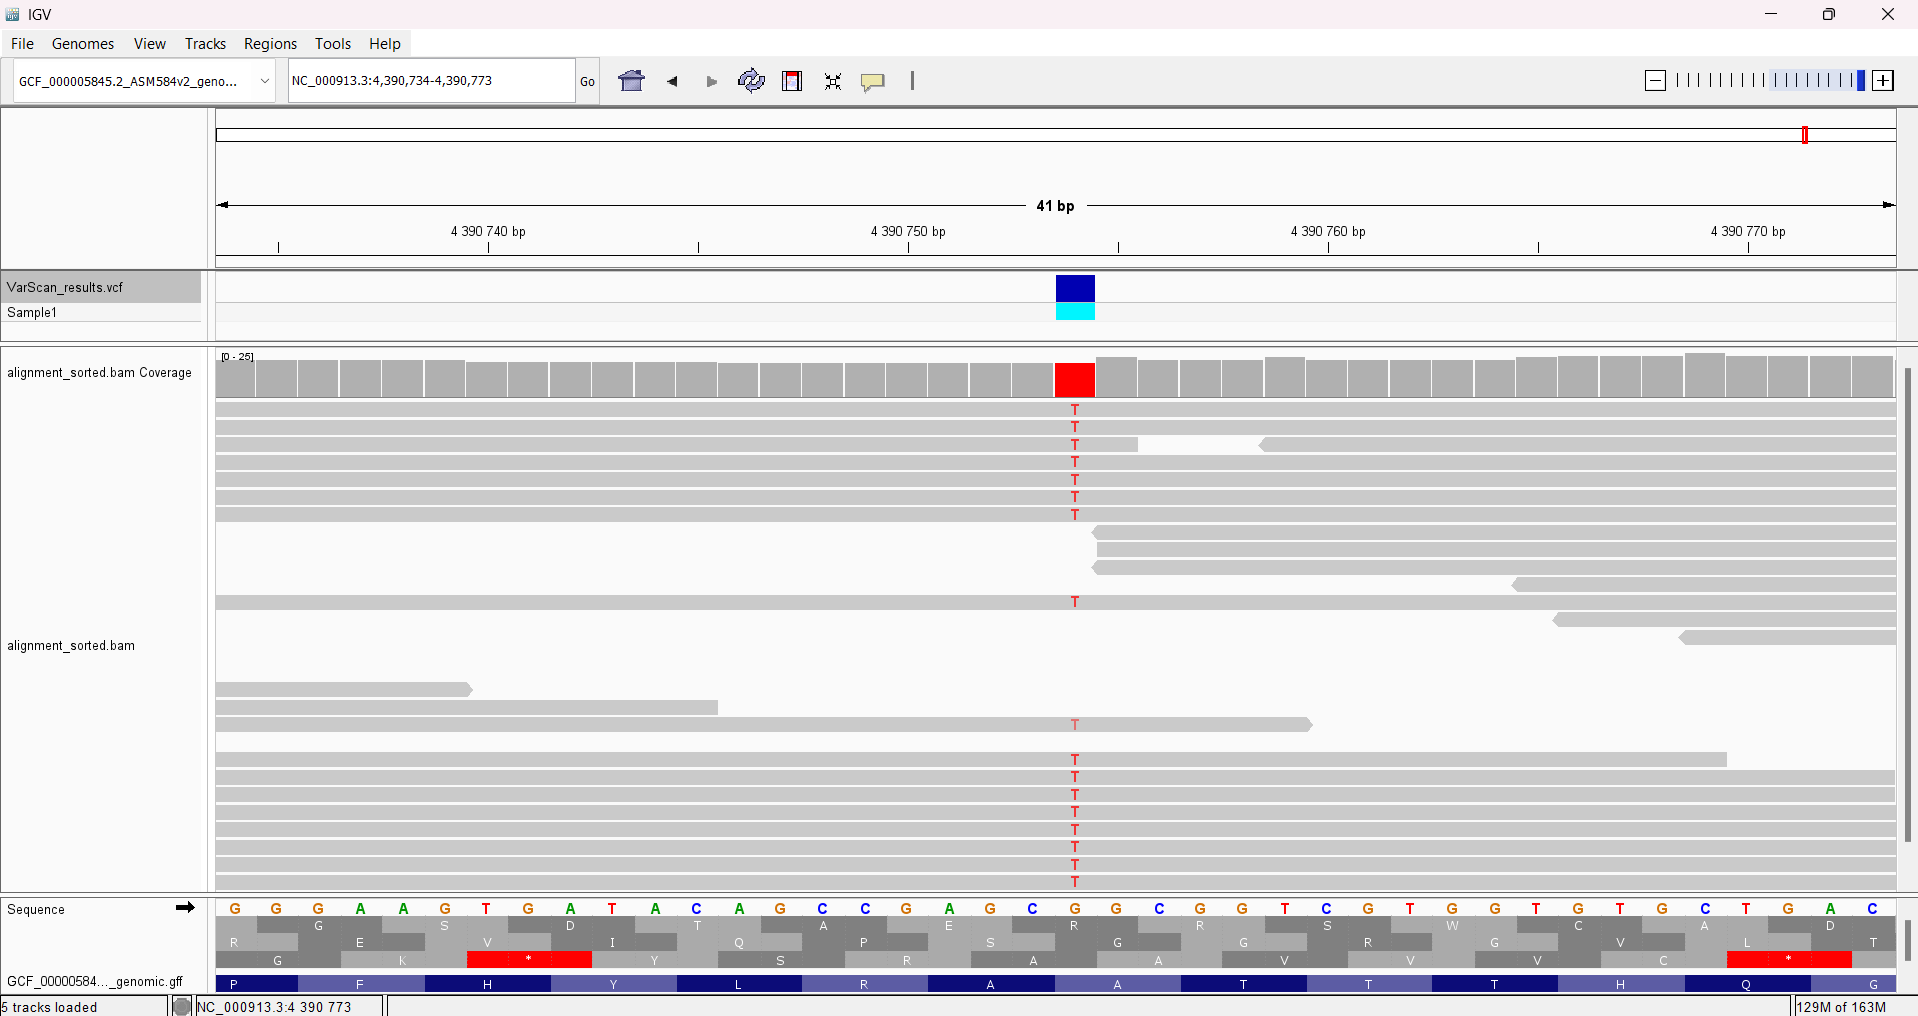

*Вывод:* однонуклеотидный полиморфизм (SNP) был идентифицирован в диапазоне NC_000913.3:4,390,734-4,390,773. Эта замена подтверждается большинством совпадающих ридов, что указывает высокую степень достоверности. В референсном геноме было эталонное основание G, которое в мутантах заменено на T.

Эта область соответствует гену rsgA (Ribosome small subunit-dependent GTPase A), участвующем в поздних стадиях созревания 30S-субъединицы рибосомы. Таким образом, данная замена не входит в область нашего интереса, потому что не связана с устойчивостью к ампициллину.

2) Результаты по второй SNP.

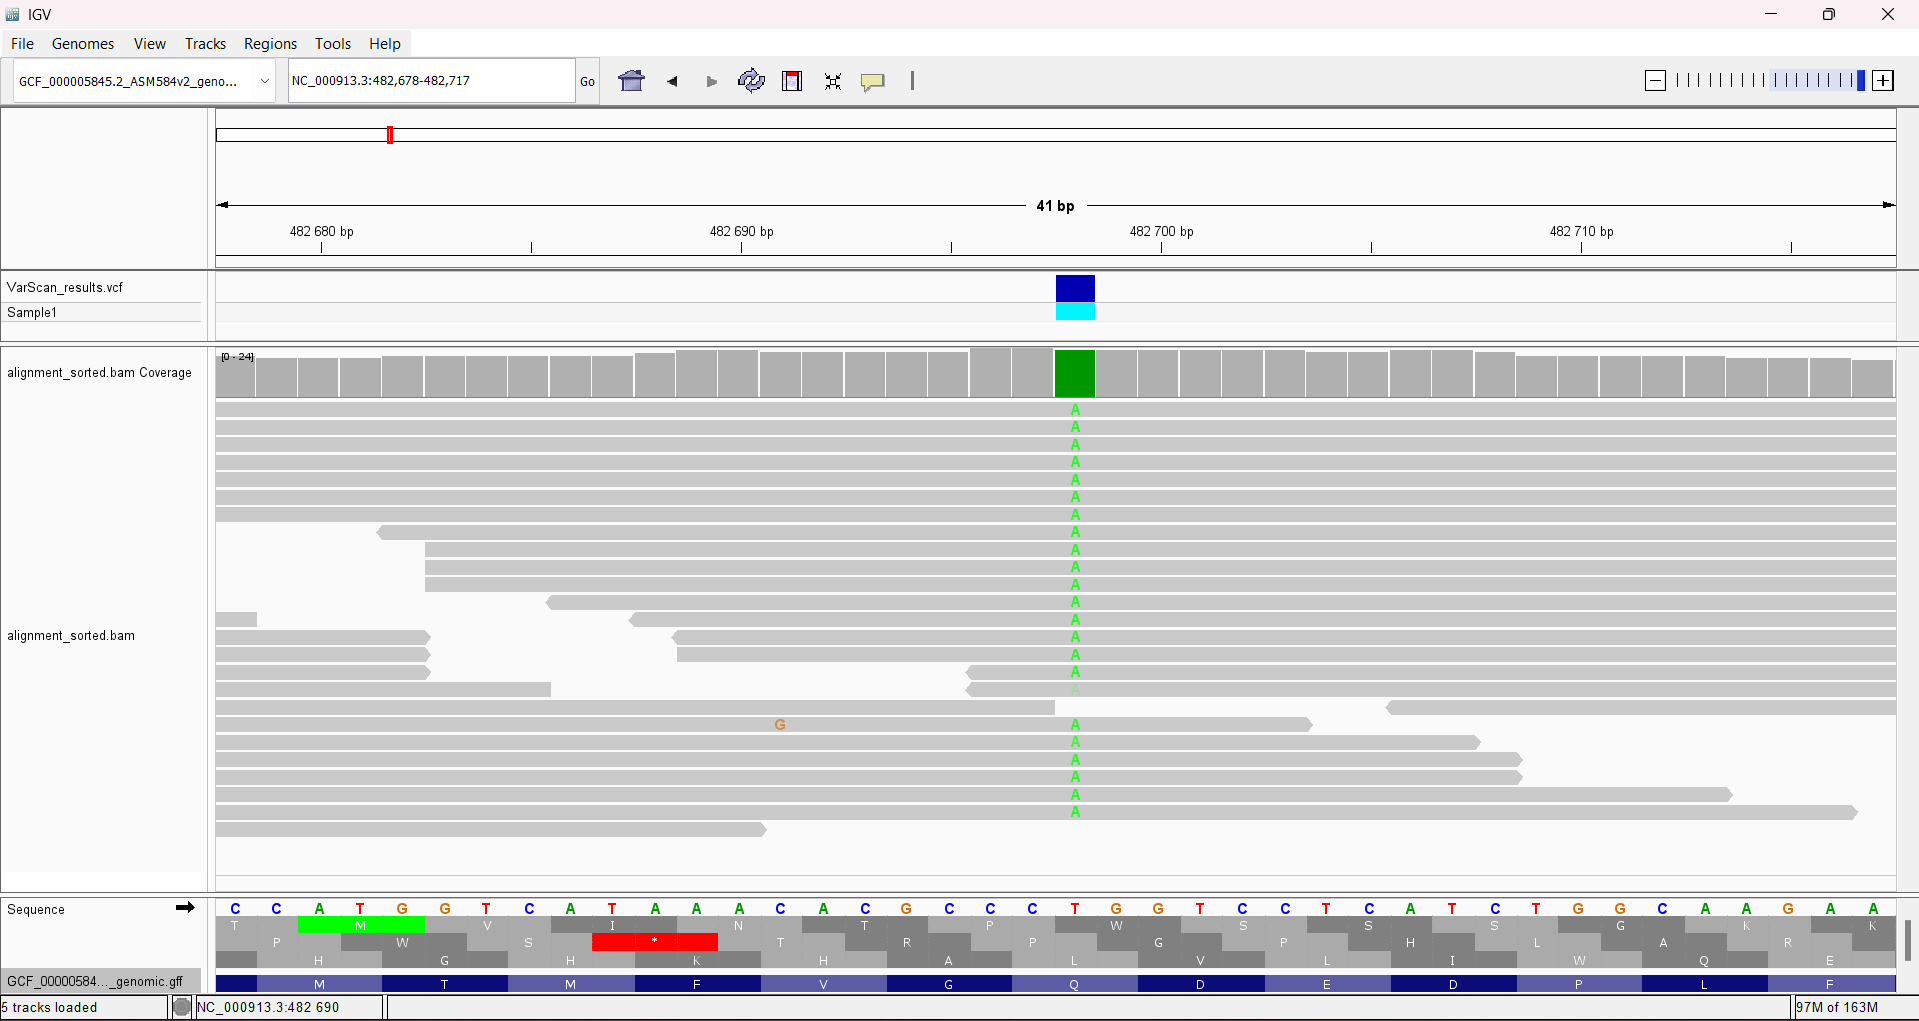

Вывод: SNP был найден в диапазоне NC_000913.3:482,678-482,717. Эта замена подтверждается большинством совпадающих ридов, что указывает высокую степень достоверности. В референсном геноме было эталонное основание Т, которое в мутантах заменено на А.

Эта область соответствует гену acrB. Белок AcrB входит в состав трёхкомпонентного эффлюксного комплекса AcrAB-TolC и является компонентом системы множественной лекарственной устойчивости. Этот белок относится к суперсемейству RND (Resistance-Nodulation-Division) и функционирует как часть эффлюксного насоса, использующий протонный градиент в качестве источника энергии для выкачивания веществ из клетки. Таким образом, данная мутация могла повлиять на формирование устойчивости исследуемого штамма к ампициллину.

3) Результаты по третьей SNP.

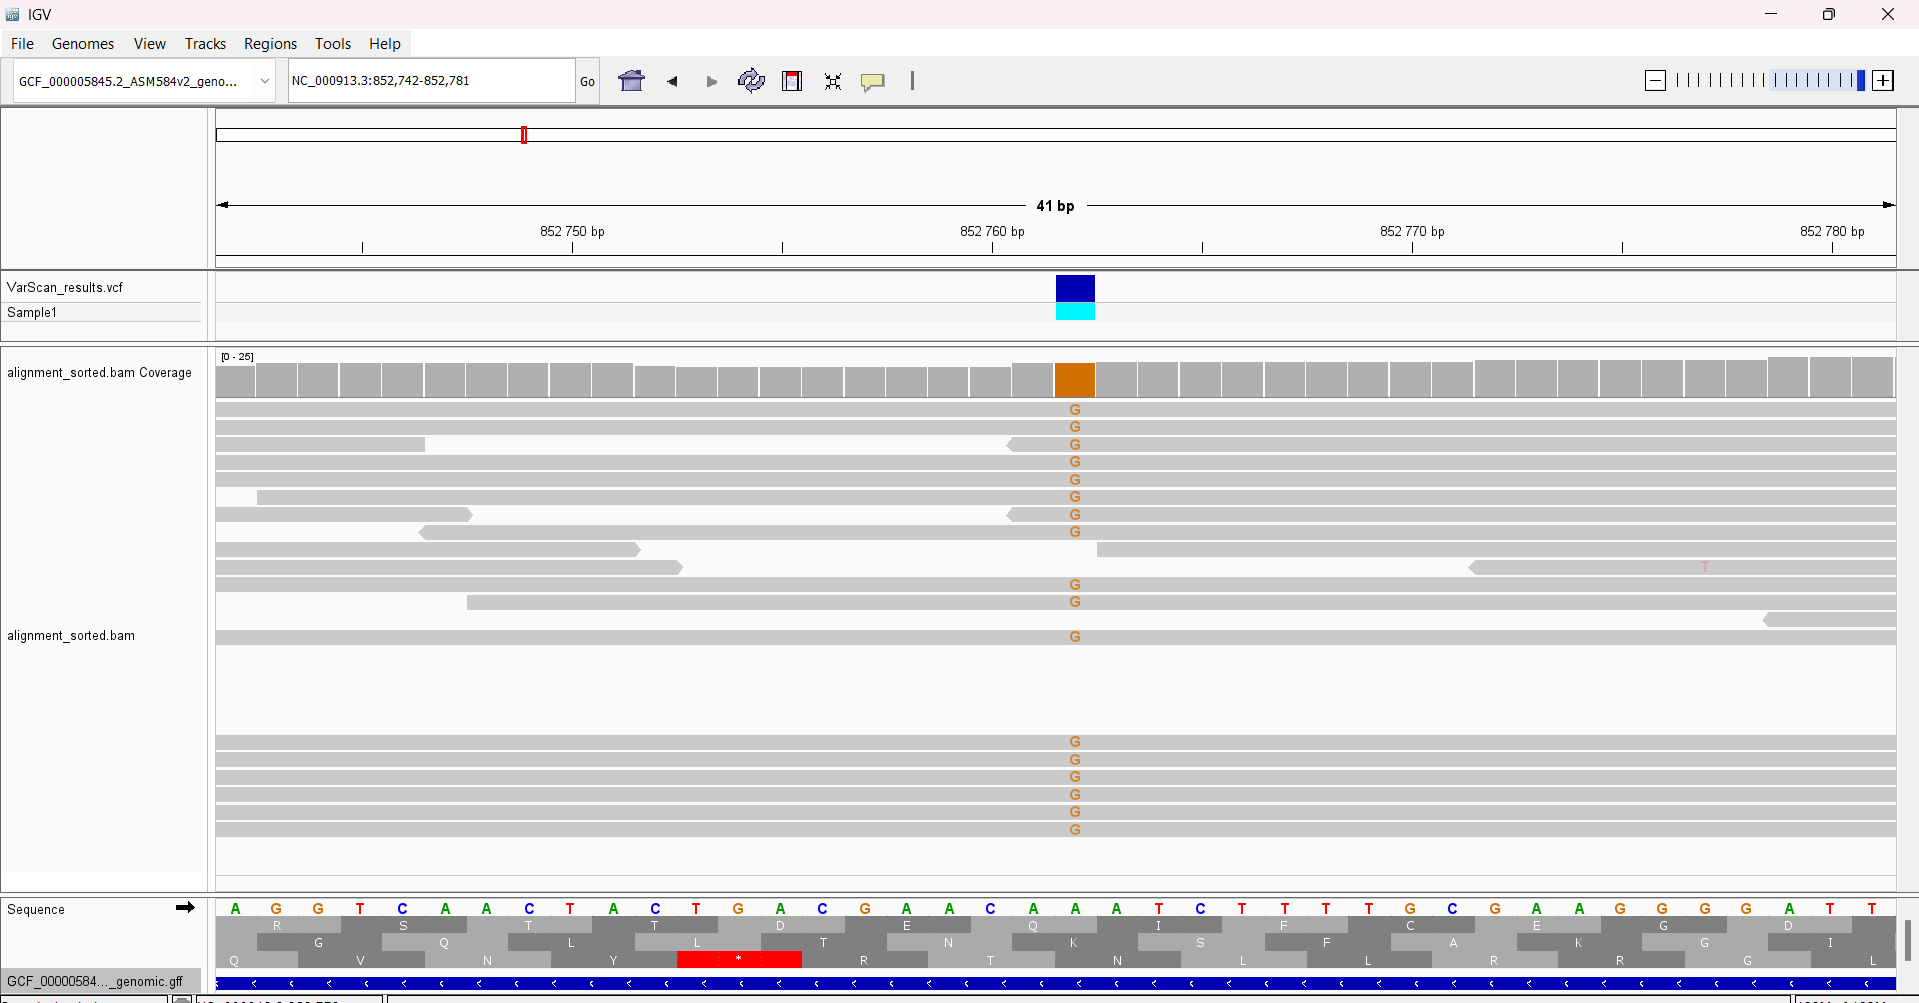

Вывод: SNP была идентифицирована в диапазоне NC_000913.3:852,742-852,781. Эта замена подтверждается большинством совпадающих ридов, что указывает высокую степень достоверности. В референсном геноме было эталонное основание A, которое в мутантах заменено на G.

Эта область соответствует участку некодирующей РНК, соответственно, не входит в область нашего интереса, потому что не связана с устойчивостью к ампициллину.

4. Результаты по четвертой SNP.

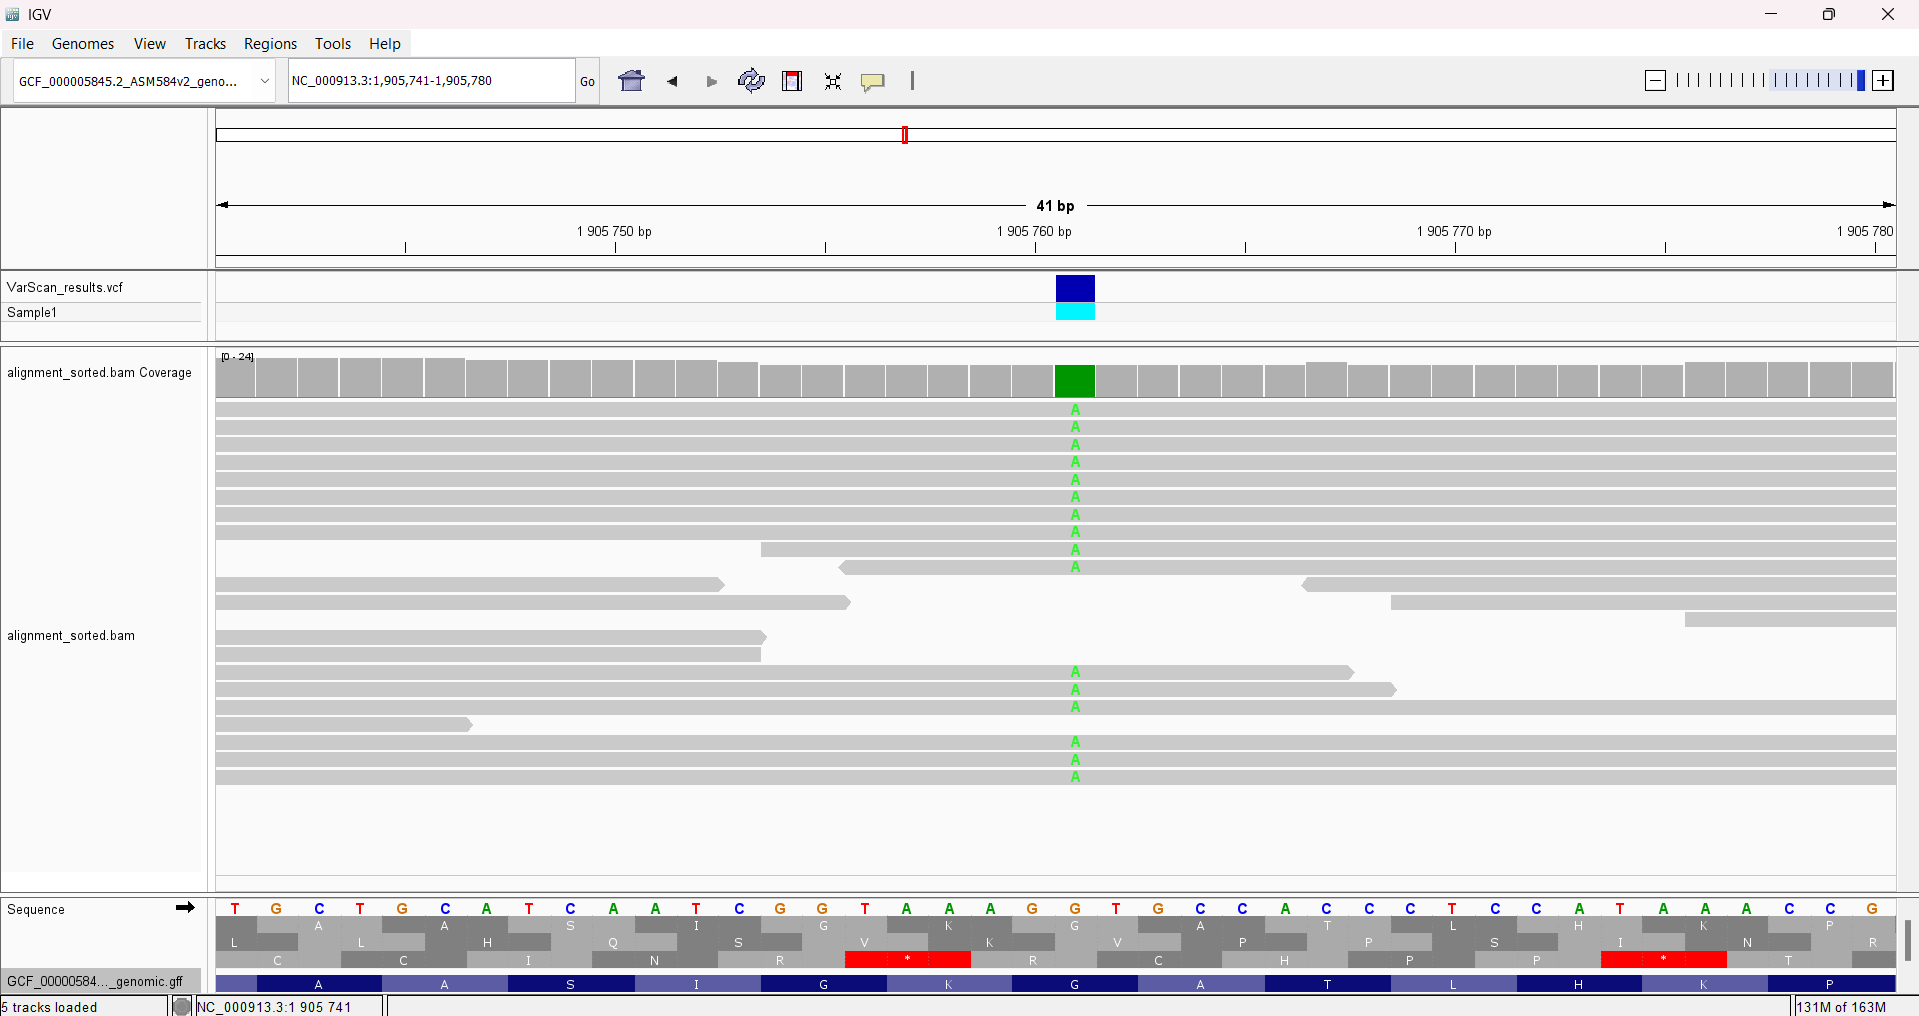

Вывод: SNP была идентифицирована в диапазоне NC_000913.3:1,905,741-1,905,780. Эта замена подтверждается большинством совпадающих ридов, что указывает высокую степень достоверности. В референсном геноме было эталонное основание G, которое в мутантах заменено на А.

Эта область соответствует гену mntP ,который у *E.coli* кодирует белок, участвующий в экспорте ионов марганца (Mn²⁺) через плазматическую мембрану, следовательно, данная замена не входит в область нашего интереса, потому что не связана с устойчивостью к ампициллину.

5. Результаты по пятой SNP.

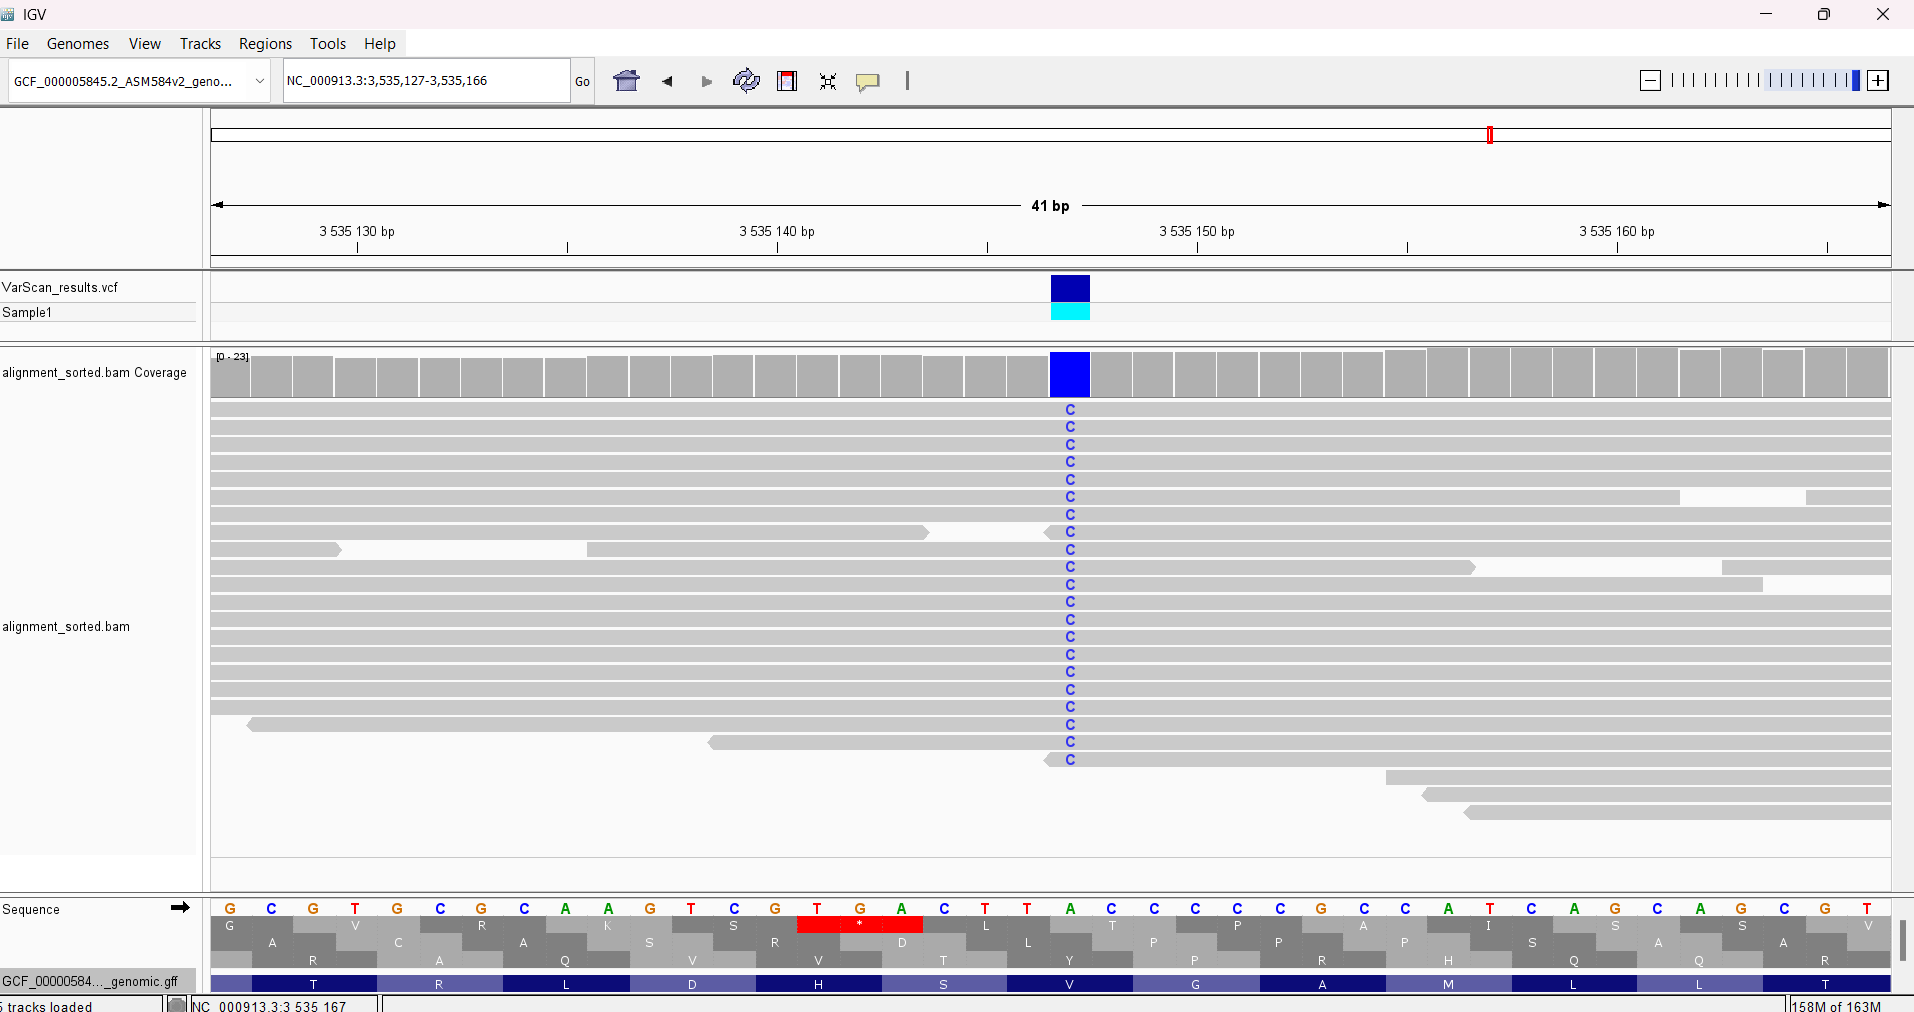

Вывод: SNP была идентифицирована в диапазоне NC_000913.3:3,535,127-3,535,166. Эта замена подтверждается большинством совпадающих ридов, что указывает высокую степень достоверности. В референсном геноме было эталонное основание А, которое в мутантах заменено на С.

Эта область соответствует гену envZ, кодирующему гистидинкиназу — мембранный белок, который играет ключевую роль в осморегуляции. Таким образом, данная замена не входит в область нашего интереса, потому что не связана с устойчивостью к ампициллину.

6. Результаты по шестой SNP.

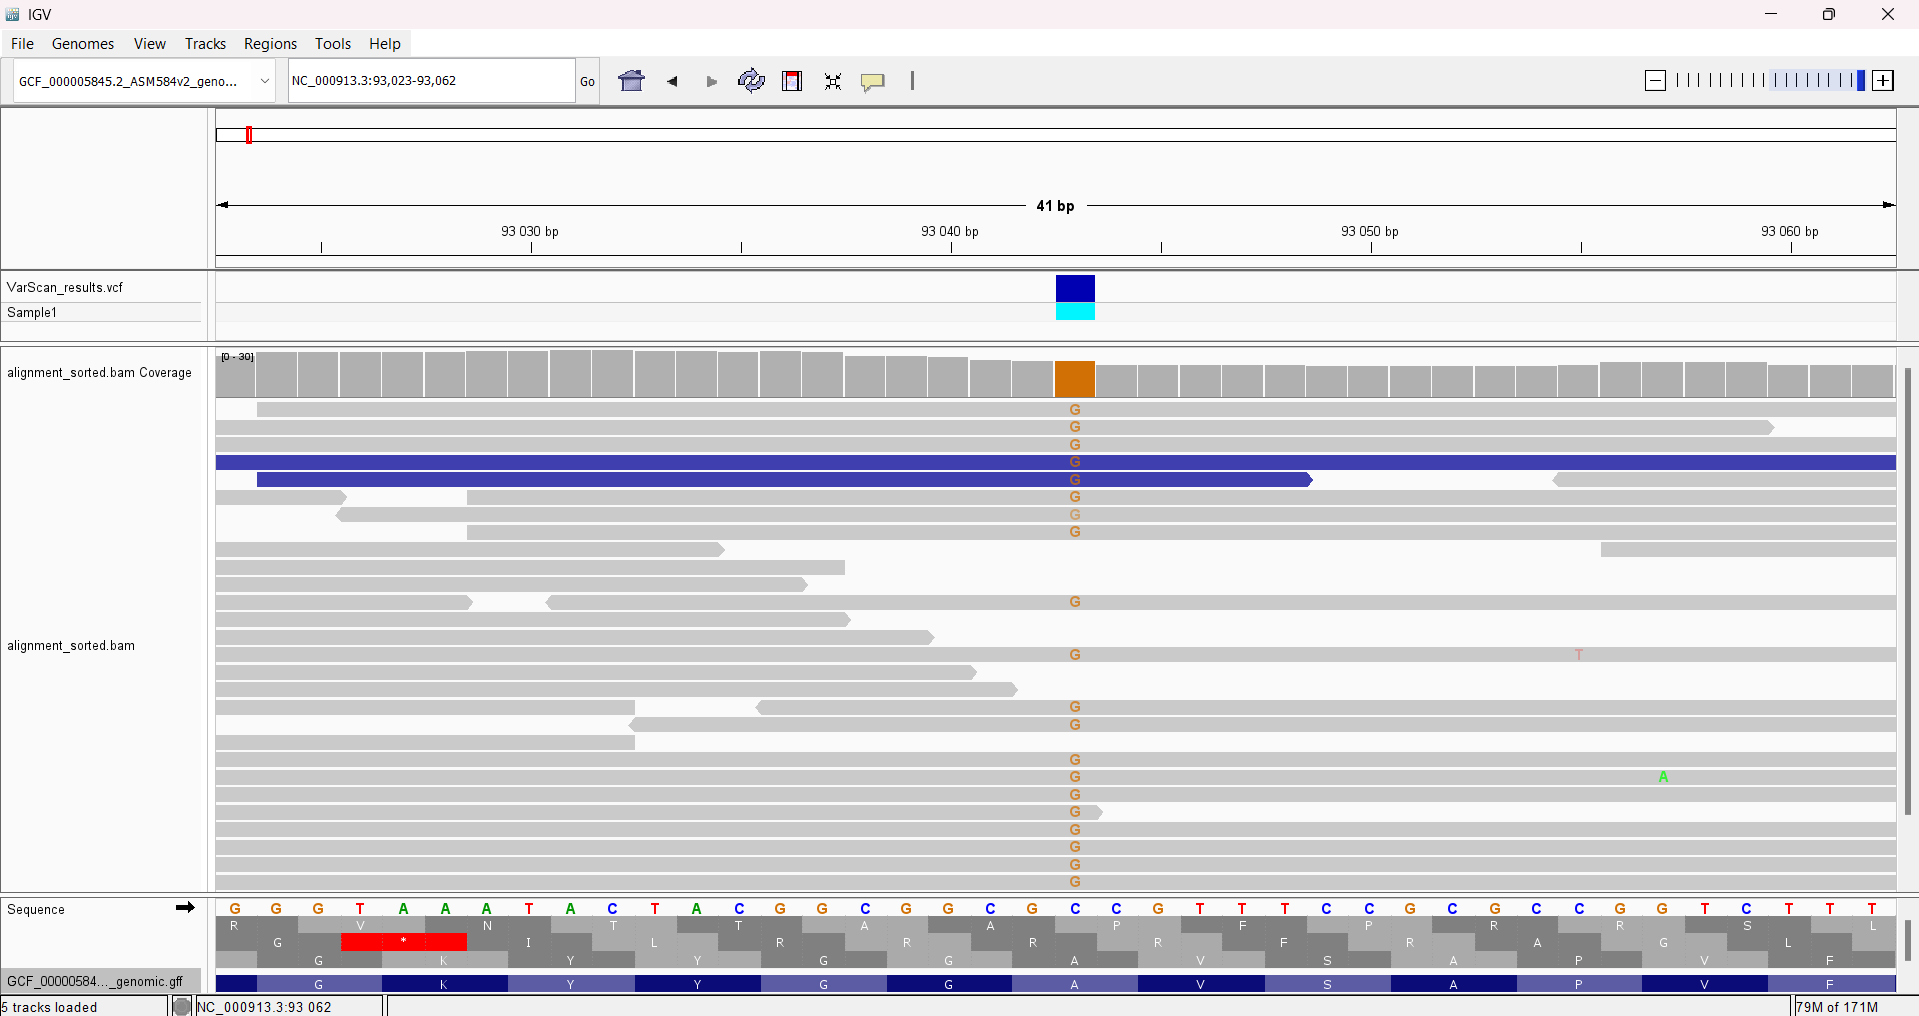

*Вывод:* SNP была идентифицирована в диапазоне NC_000913.3:3,535,127-3,535,166. Эта замена подтверждается большинством совпадающих ридов, что указывает высокую степень достоверности. В референсном геноме было эталонное основание G, которое в мутантах заменено на С.

Эта область соответствует гену ftsI, который кодирует пенициллинсвязывающий белок 3 (PBP3 - Penicillin-Binding Protein 3) — ключевой фермент, участвующий в синтезе пептидогликана во время деления клеток. β-лактамные антибиотики воздействуют на PBP3, подавляя его транспептидазную активность. Выявленная миссенс-мутация (p.Ala544Gly) может изменять структуру PBP3, снижая его способность связываться с антибиотиками, но при этом сохраняя ферментативную функцию. Это позволяет предположить, что механизм модификации мишени способствует развитию устойчивости к антибиотикам, в том числе и к ампициллину, что важно для нашего исследования.

**Общий вывод по мануальному поиску SNP:**

В ходе анализа SNP путем самостоятельного поиска в IGV, было выявлено шесть регионов с заменами, четыре из которых не относились к генам, обеспечивающим устойчивость к антибиотикам. Но мутация в регионе NC_000913.3:482,678-482,717, соответствующем гену acrB, который является частью эффлюксного насоса, участвующего в удалении токсичных веществ из клеток бактерий, в том числе и в удалении антибиотиков, что и обеспечивает устойчивость к ампициллину. А также SNP в последовательности гена ftsI может привести к изменению структуры кодируемого пенициллинсвязывающего белка и обеспечивать антибиотикорезистентность.

19. Воспользуемся автоматической аннотацией SNP для подтверждения или опровержения полученных выводов.

Сначала установим SnpEff.

In [ ]:
conda install snpeff

Затем нужно скачать референсную последовательность и аннотацию к ней из NCBI.

In [ ]:
wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz

Далее переходим к созданию базы данных:

Для начала создаем пустой текстовый файл SnpEff.config только с одной строкой.

In [ ]:
mkdir -p data/k12

Распаковываем файл с аннотацией, переименовываем его и переносим в созданную папку.

In [ ]:
gunzip GCF_000005845.2_ASM584v2_genomic.gbff.gz
cp GCF_000005845.2_ASM584v2_genomic.gbff data/k12/genes.gbk

Превращаем папку k12 в конфигурационный файл для SnpEff.

In [ ]:
echo "k12.genome : ecoli_K12" > snpEff.config

Затем пишем команду для завершения создания базы данных.

In [ ]:
snpEff build -genbank -v k12

Теперь запускаем SnpEff для описания эффектов каждой SNP.

In [ ]:
snpEff ann k12 VarScan_results.vcf > VarScan_results_annotated.vcf

Затем проверяем, отработал ли инструмент SnpEff.

In [ ]:
head VarScan_results_annotated.vcf

Увидели первые строки с информацией и фильтрами, а, значит, всё сработало.

Затем необходимо преобразовать результаты в табличный вид.

In [ ]:
awk 'BEGIN{FS="\t"; OFS=","}
!/^#/ {
  split($8,a,"ANN=");
  split(a[2],b,",");
  split(b[1],c,"|");
  print $2, $4">"$5, c[4], c[2], c[11]
}' VarScan_results_annotated.vcf > results.csv

Теперь получившийся файл с таблицей откроем с помощью команд на Python.

In [5]:
import pandas as pd

In [13]:
df = pd.read_csv("SNP_results.csv", header=None,
                 names=["Position", "SNP", "Gene", "Effect", "Protein"])
df.head(6)

,Position,SNP,Gene,Effect,Protein
0,93043,C>G,ftsI,missense_variant,p.Ala544Gly
1,482698,T>A,acrB,missense_variant,p.Gln569Leu
2,852762,A>G,glnH,upstream_gene_variant,NaN
3,1905761,G>A,mntP,missense_variant,p.Gly25Asp
4,3535147,A>C,envZ,missense_variant,p.Val241Gly
5,4390754,G>T,rsgA,synonymous_variant,p.Ala252Ala


**Вывод:** автоматическое аннотирование SNP с использованием SnpEff выявило несколько мутаций в исследуемом устойчивом штамме E. coli.
Четыре замены были классифицированы как миссенс-мутации в генах, кодирующих белки: ftsI, AcrB, mntP и envZ, что указывает на изменения аминокислоты в месте мутации и, как следствие, изменение последовательности закодированных белков.
Одна мутация была локализована выше гена glnH и классифицирована как замена в промоторной области данного гена, что может влиять на его регуляцию.
Мутаций, приводящий к появлению стоп-кодонов (нонсенс-мутации) не отмечается.
В гене rsgA была идентифицирована синонимичная мутация, что указывает на отсутствие аминокислотных замен и изменений в последовательности белка.

                                         Основные выводы:

Результаты автоматической аннотации SNP с использованием SnpEff подтвердили выводы, полученные при ручном анализе данных в IGV. Применяя оба подхода, были выявлены одни и те же ключевые замены, включая мутации в генах ftsI, acrB и envZ, которые потенциально связанны с устойчивостью к антибиотикам.

В частности, мутация в гене ftsI, обнаруженная при мануальном анализе, была автоматически классифицирована как missense-вариант (p.Ala544Gly). Это подтверждает предположение о возможной модификации мишени β-лактамных антибиотиков — пенициллинсвязывающего белка PBP3. Аналогично, мутация в гене acrB, кодирующем компонент эффлюксного насоса, также была подтверждена как missense-мутация, что указывает на возможное усиление выведения антибиотика из клетки. Замена в гене envZ, выявленная вручную, была автоматически аннотирована как missense-мутация, и появляется гипотеза о возможном влиянии данной замены на регуляцию проницаемости клеточной мембраны и соответственном снижении проницаемости мембраны для ампициллина, что будет влиять на появление устойчивости у исследуемой бактерии.

Кроме того, автоматический анализ позволил уточнить функциональные последствия других мутаций. Так, замена в области гена glnH была классифицирована как upstream gene variant, что указывает на потенциальное влияние на регуляцию экспрессии гена. Мутация в гене mntP была определена как missense,а в гене rsgA была обнаружена синонимичная мутация, не приводящая к изменению аминокислотной последовательности белка.

Таким образом, автоматическая аннотация не только подтвердила результаты мануального анализа, но и позволила их углубить: более точно классифицировать типы мутаций и их возможные функциональные последствия. Совокупность выявленных missense-мутаций в генах ftsI, acrB и envZ указывает на возможный комбинированный механизм устойчивости, включающий модификацию мишени антибиотика, усиление эффлюкса и изменение проницаемости клеточной мембраны.